<a href="https://colab.research.google.com/github/arjunnp20-design/first/blob/main/HOME_LOAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PRCP-1006-HOMELOANDEF**

###**TEAM-CODE : PTID-CDS-MAY-26-11231**

####**PROBLEM STATEMENT**:

TASK 1: Prepare a complete data analysis report on the given data.

TASK 2 : Create a predictive model to identifiy the factors / customer segment that are eligible for taking loan.

###**Data Description**

application_train.csv
*   the main file which contains the target (1:defaulter ; 0: defaulter)
*   static data for all applications.One row represents one loan in our data sample.

bureau.csv
*   all clients previous credits provided by other financial institutions that were reported to credit bureau(for clients who have a loan in our sample)
*   for every loan in our sample there are many rows as number of credicts the client had in credit bureau before the application date.

bureau_balance.csv
*   mouthly balances of previous credits in credit bureau.
*   this table has one row for each month of history of every previous credit reported to credit bureau - i.e the table has (#loans in sample *# of relative previous credit *# of months where we have some history observable for the previous credits) rows.

POS_CASH_balance.csv
*   Monthly balance snapshots of previous POS(point of sales) and cash loans that the applicant had with home credit.
*   this table has one row for each month of history of every previous credit in home credit( consumrt credit and cash loans)related to loans in our sample - i.e. the table has (#loans in sample *# of relative previous crredits*# of months in which we have some history observable for previous credits) rows.

credit_card_balance.csv
*    Montly balance snapshots of previous credit cards that the applicant has with home credit.
*    this able has one row for each month of history of every previous credit in home credit this table has (#loans in sample *# of relative previous credit card )rows.

previous_application.csv
*    all previous application dor home credit loans in our sample.
*    there is one row for each previous applicatioon related to loans in our data sample.

installments_payment.csv
*    repayment history for thr previous disbursed credit in home credit related to the loans in our sample.
*   there is a one row for every payment that was made plus one row each for missed payment.
*   one row is equalient to one payment of the previous home credit related to loans in our sample.


#**EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
application_train = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')
bureau_balance = pd.read_csv('bureau_balance.csv')
credit_card_balance = pd.read_csv('credit_card_balance.csv')
installments_payment = pd.read_csv('installments_payments.csv')
pos_cash_balance = pd.read_csv('POS_CASH_balance.csv')
previous_application = pd.read_csv('previous_application.csv')

In [ ]:
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497.0,0.0,-153.0,-153.0,NaN,0.0,91323.00,0.000,NaN,0.0,Consumer credit,-131.0,NaN
1,215354,5714463,Active,currency 1,-208.0,0.0,1075.0,NaN,NaN,0.0,225000.00,171342.000,NaN,0.0,Credit card,-20.0,NaN
2,215354,5714464,Active,currency 1,-203.0,0.0,528.0,NaN,NaN,0.0,464323.50,NaN,NaN,0.0,Consumer credit,-16.0,NaN
3,215354,5714465,Active,currency 1,-203.0,0.0,NaN,NaN,NaN,0.0,90000.00,NaN,NaN,0.0,Credit card,-16.0,NaN
4,215354,5714466,Active,currency 1,-629.0,0.0,1197.0,NaN,77674.5,0.0,2700000.00,NaN,NaN,0.0,Consumer credit,-21.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539517,139219,5490064,Closed,currency 1,-2504.0,0.0,-2168.0,-2380.0,0.0,0.0,38832.30,0.000,0.000,0.0,Consumer credit,-2380.0,NaN
539518,139219,5490065,Active,currency 1,-2401.0,0.0,-1378.0,NaN,0.0,0.0,45000.00,-29.475,29.475,0.0,Credit card,-666.0,NaN
539519,139219,5490067,Closed,currency 1,-1026.0,0.0,-690.0,-719.0,8685.0,0.0,77937.84,0.000,0.000,0.0,Consumer credit,-719.0,NaN
539520,139219,5490068,Closed,currency 1,-1644.0,0.0,-1553.0,-1583.0,NaN,0.0,12595.50,0.000,0.000,0.0,Consumer credit,-1533.0,NaN


In [ ]:
bureau_balance

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0.0,C
1,5715448,-1.0,C
2,5715448,-2.0,C
3,5715448,-3.0,C
4,5715448,-4.0,C
...,...,...,...
3431837,5903462,-34.0,X
3431838,5903462,-35.0,X
3431839,5903462,-36.0,X
3431840,5903462,-37.0,X


In [ ]:
credit_card_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1.0,0.0,1.0,35.0,Active,0.0,0.0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1.0,0.0,0.0,69.0,Active,0.0,0.0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0.0,0.0,0.0,30.0,Active,0.0,0.0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1.0,0.0,0.0,10.0,Active,0.0,0.0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1.0,0.0,1.0,101.0,Active,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375248,1825813,451354,-72,67155.975,135000,0.0,0.0,0.0,0.0,6750.000,...,67155.975,67155.975,0.0,0.0,0.0,0.0,30.0,Active,0.0,0.0
375249,2710392,177998,-65,0.000,0,0.0,0.0,0.0,0.0,0.000,...,0.000,0.000,0.0,0.0,0.0,0.0,26.0,Active,0.0,0.0
375250,2841600,324315,-67,89361.000,90000,0.0,0.0,0.0,0.0,4500.000,...,89361.000,89361.000,0.0,0.0,0.0,0.0,21.0,Active,0.0,0.0
375251,1277605,217317,-63,108749.250,112500,10350.0,10350.0,0.0,0.0,5625.000,...,108749.250,108749.250,1.0,1.0,0.0,0.0,31.0,Active,0.0,0.0


In [ ]:
installments_payment

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674.0,1.0,6.0,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639.0,0.0,34.0,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053.0,2.0,1.0,-63.0,-63.0,25425.000,25425.000
3,2452527,199697.0,1.0,3.0,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756.0,1.0,2.0,-1383.0,-1366.0,2165.040,2160.585
...,...,...,...,...,...,...,...,...
631316,1169047,164940.0,1.0,21.0,-263.0,-284.0,30137.085,19063.035
631317,2090446,139470.0,1.0,10.0,-380.0,-380.0,28502.820,28502.820
631318,2610996,149165.0,2.0,16.0,-467.0,-501.0,57788.730,57788.730
631319,2172740,101274.0,2.0,4.0,-928.0,-961.0,19493.550,19493.550


In [ ]:
pos_cash_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0.0,0.0
1,1715348,367990,-33,36.0,35.0,Active,0.0,0.0
2,1784872,397406,-32,12.0,9.0,Active,0.0,0.0
3,1903291,269225,-35,48.0,42.0,Active,0.0,0.0
4,2341044,334279,-35,36.0,35.0,Active,0.0,0.0
...,...,...,...,...,...,...,...,...
1974261,2568571,300077,-8,12.0,12.0,Active,0.0,0.0
1974262,1865933,199846,-13,24.0,5.0,Active,0.0,0.0
1974263,1436889,304930,-8,24.0,8.0,Active,0.0,0.0
1974264,1724146,395447,-14,24.0,5.0,Active,0.0,0.0


In [ ]:
previous_application

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339888,2320911,269255,Consumer loans,6923.835,35955.0,33957.0,3600.0,35955.0,FRIDAY,4,...,Connectivity,6.0,high,POS mobile with interest,365243.0,-1446.0,-1296.0,-1296.0,-1289.0,0.0
339889,1541879,286761,Cash loans,105683.310,540000.0,550692.0,NaN,540000.0,FRIDAY,11,...,XNA,6.0,middle,Cash Street: middle,NaN,NaN,NaN,NaN,NaN,NaN
339890,1639559,149875,Revolving loans,11250.000,225000.0,225000.0,NaN,225000.0,SATURDAY,11,...,Consumer electronics,0.0,XNA,Card Street,-569.0,-527.0,365243.0,-313.0,-202.0,0.0
339891,2032587,181303,Consumer loans,2066.940,19557.0,21492.0,0.0,19557.0,TUESDAY,16,...,Consumer electronics,12.0,low_action,POS household without interest,NaN,NaN,NaN,NaN,NaN,NaN


###**application_train**

In [ ]:
application_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89232,203603,0,Cash loans,M,N,Y,1,135000.0,247500.0,12766.5,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
89233,203604,0,Cash loans,F,N,Y,0,112500.0,270000.0,16645.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
89234,203607,0,Cash loans,M,Y,Y,0,225000.0,568197.0,29142.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
89235,203608,0,Cash loans,M,Y,Y,2,247500.0,871029.0,44604.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [ ]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
application_train.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
89232,203603,0,Cash loans,M,N,Y,1,135000.0,247500.0,12766.5,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
89233,203604,0,Cash loans,F,N,Y,0,112500.0,270000.0,16645.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
89234,203607,0,Cash loans,M,Y,Y,0,225000.0,568197.0,29142.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
89235,203608,0,Cash loans,M,Y,Y,2,247500.0,871029.0,44604.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
89236,203609,0,Cash loans,F,Y,Y,1,135000.0,316125.0,20331.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
application_train.shape

(89237, 122)

In [ ]:
application_train.dtypes

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64


In [ ]:
application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89237 entries, 0 to 89236
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(85), int64(21), object(16)
memory usage: 83.1+ MB


In [ ]:
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,89237.000000,89237.000000,89237.000000,8.923700e+04,8.923700e+04,89231.000000,8.916000e+04,89237.000000,89237.000000,89237.000000,...,89236.000000,89236.000000,89236.000000,89236.000000,77273.00000,77273.000000,77273.000000,77273.000000,77273.000000,77273.000000
mean,151752.082567,0.080706,0.416699,1.694528e+05,5.987953e+05,27066.818578,5.381043e+05,0.020849,-16033.026917,63382.939330,...,0.008483,0.000639,0.000459,0.000303,0.00660,0.007208,0.033556,0.269486,0.266108,1.893262
std,29853.306338,0.272385,0.721152,4.045315e+05,4.018051e+05,14441.748685,3.691735e+05,0.013809,4369.486636,140920.125894,...,0.091713,0.025266,0.021430,0.017392,0.08533,0.105679,0.202224,0.923574,0.614251,1.876291
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1980.000000,4.500000e+04,0.000533,-25201.000000,-17531.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125967.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16456.500000,2.385000e+05,0.010006,-19676.000000,-2764.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,151689.000000,0.000000,0.000000,1.440000e+05,5.124465e+05,24903.000000,4.500000e+05,0.018850,-15756.000000,-1216.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,177607.000000,0.000000,1.000000,2.025000e+05,8.086500e+05,34587.000000,6.795000e+05,0.028663,-12384.000000,-290.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.000000
max,203609.000000,1.000000,12.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7676.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,3.00000,6.000000,8.000000,24.000000,8.000000,25.000000


In [ ]:
application_train.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,11964
AMT_REQ_CREDIT_BUREAU_WEEK,11964
AMT_REQ_CREDIT_BUREAU_MON,11964
AMT_REQ_CREDIT_BUREAU_QRT,11964


In [ ]:
application_train.nunique()

,0
SK_ID_CURR,89237
TARGET,2
NAME_CONTRACT_TYPE,2
CODE_GENDER,3
FLAG_OWN_CAR,2
...,...
AMT_REQ_CREDIT_BUREAU_DAY,7
AMT_REQ_CREDIT_BUREAU_WEEK,8
AMT_REQ_CREDIT_BUREAU_MON,21
AMT_REQ_CREDIT_BUREAU_QRT,9


In [ ]:
application_train.duplicated().sum()

np.int64(0)

In [ ]:
application_train['TARGET'].value_counts()

,count
TARGET,
0,82035
1,7202


<Axes: >

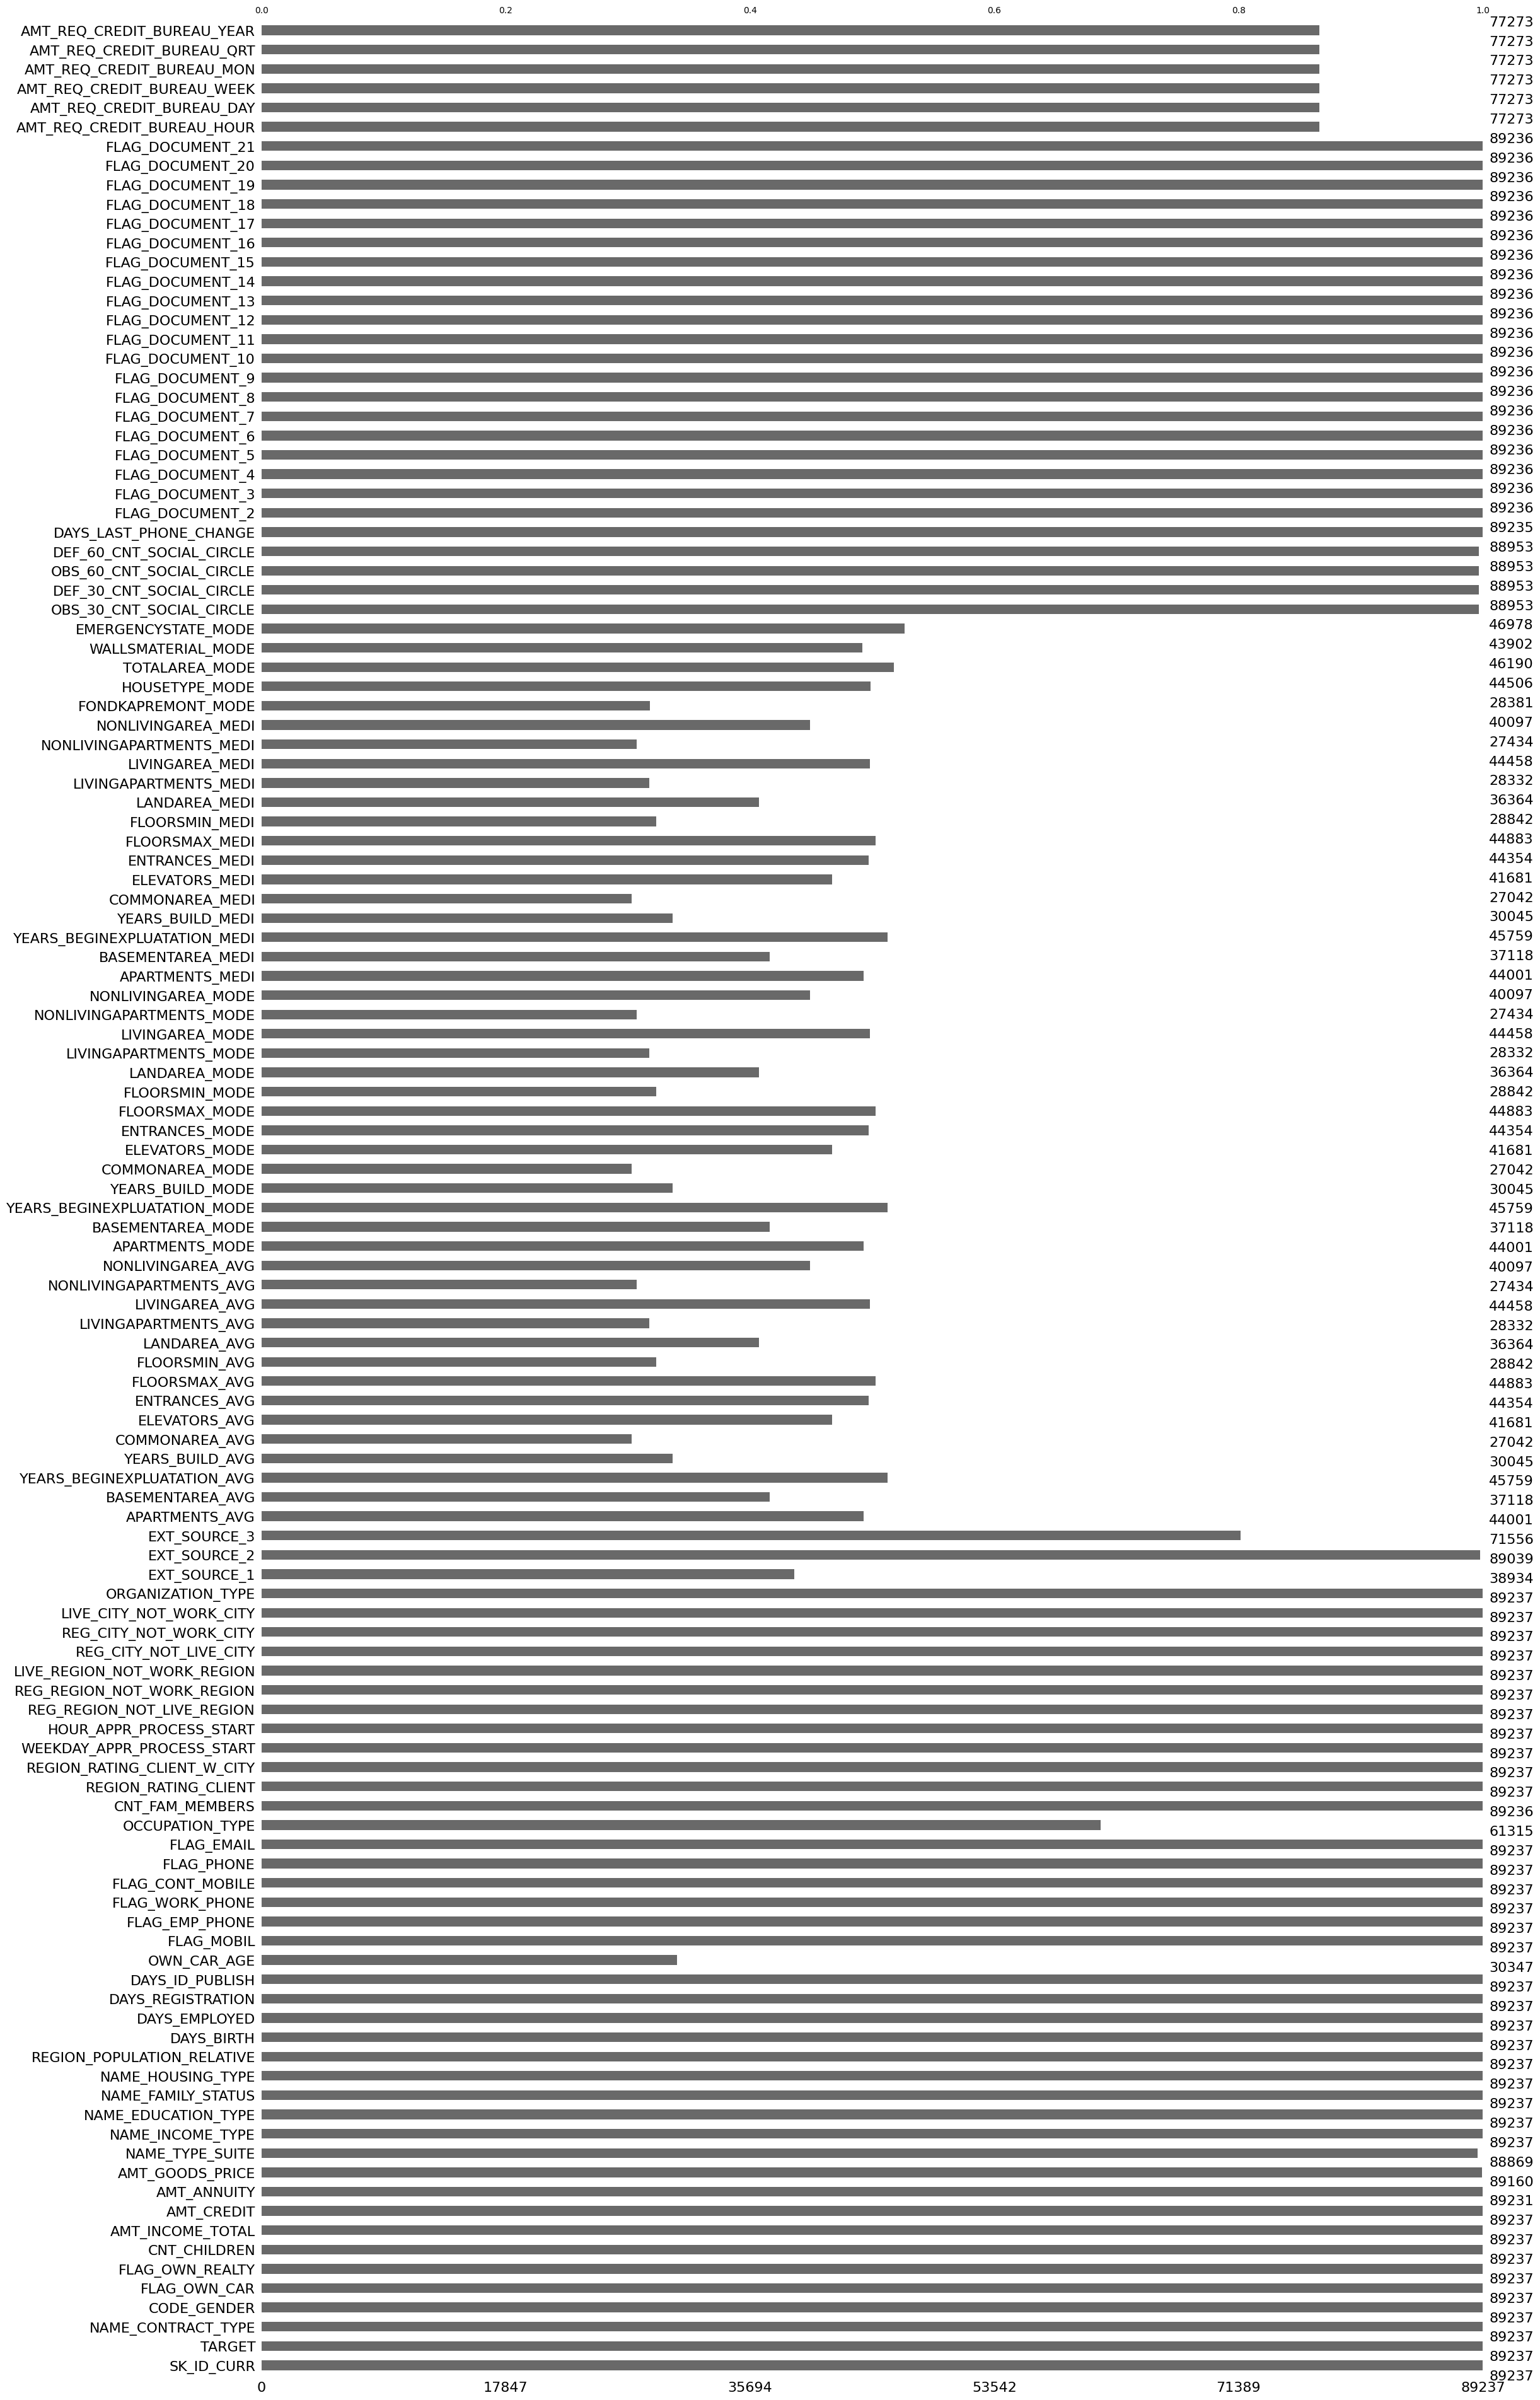

In [ ]:
import missingno as msno
msno.bar(application_train)

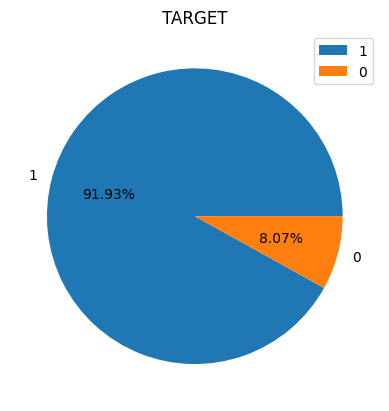

In [ ]:
plt.pie(application_train['TARGET'].value_counts(),labels=application_train['TARGET'].unique(),autopct='%0.2f%%')
plt.legend()
plt.title('TARGET')
plt.show()

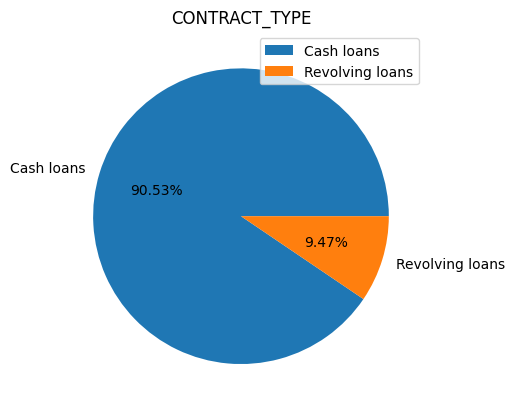

In [ ]:
plt.pie(application_train['NAME_CONTRACT_TYPE'].value_counts(),labels=application_train['NAME_CONTRACT_TYPE'].unique(),autopct='%0.2f%%')
plt.legend()
plt.title('CONTRACT_TYPE')
plt.show()

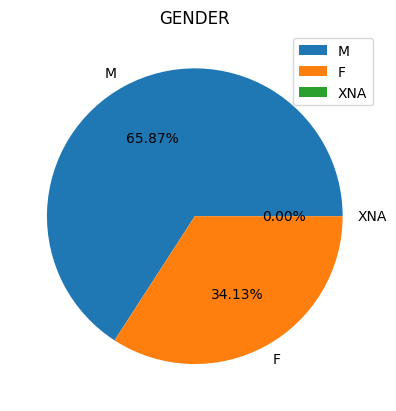

In [ ]:
plt.pie(application_train['CODE_GENDER'].value_counts(),labels=application_train['CODE_GENDER'].unique(),autopct='%0.2f%%')
plt.legend()
plt.title('GENDER')
plt.show()

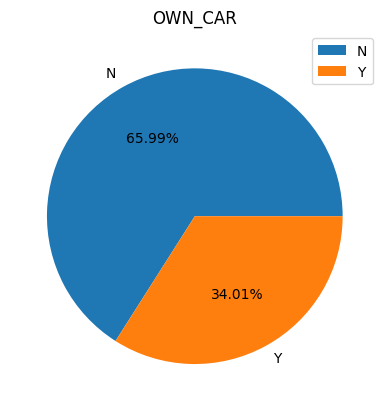

In [ ]:
plt.pie(application_train['FLAG_OWN_CAR'].value_counts(),labels=application_train['FLAG_OWN_CAR'].unique(),autopct='%0.2f%%')
plt.legend()
plt.title('OWN_CAR')
plt.show()

In [ ]:
application_train['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,46274
Commercial associate,20706
Pensioner,15958
State servant,6278
Unemployed,9
Student,8
Businessman,3
Maternity leave,1


<function matplotlib.pyplot.show(close=None, block=None)>

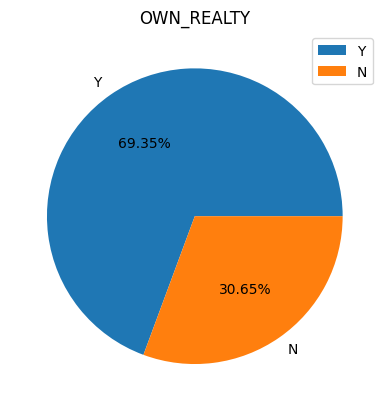

In [ ]:
plt.pie(application_train['FLAG_OWN_REALTY'].value_counts(),labels=application_train['FLAG_OWN_REALTY'].unique(),autopct='%0.2f%%')
plt.legend()
plt.title('OWN_REALTY')
plt.show

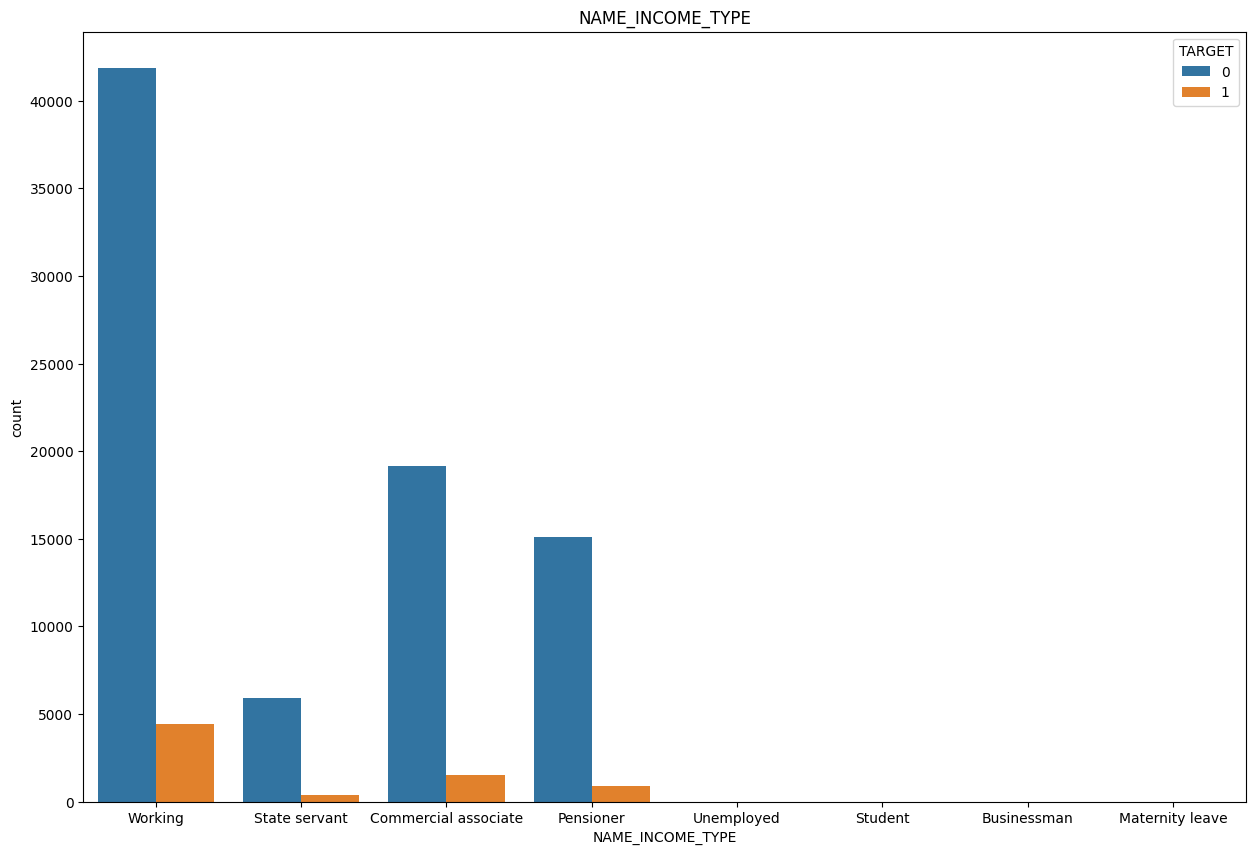

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x='NAME_INCOME_TYPE',hue='TARGET',data=application_train)
plt.title('NAME_INCOME_TYPE')
plt.show()

In [ ]:
application_train['NAME_EDUCATION_TYPE'].value_counts()

,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,63464
Higher education,21747
Incomplete higher,2888
Lower secondary,1096
Academic degree,42


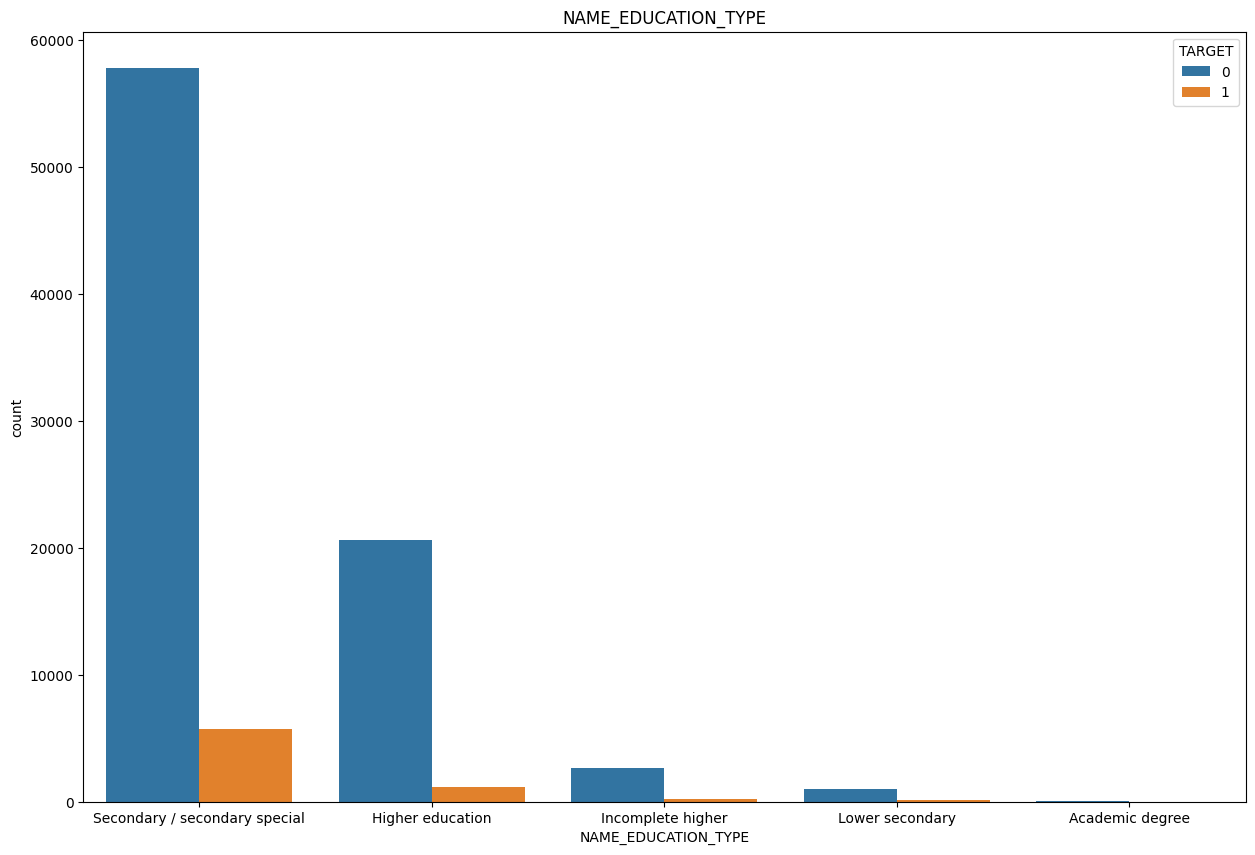

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x='NAME_EDUCATION_TYPE',hue='TARGET',data=application_train)
plt.title('NAME_EDUCATION_TYPE')
plt.show()

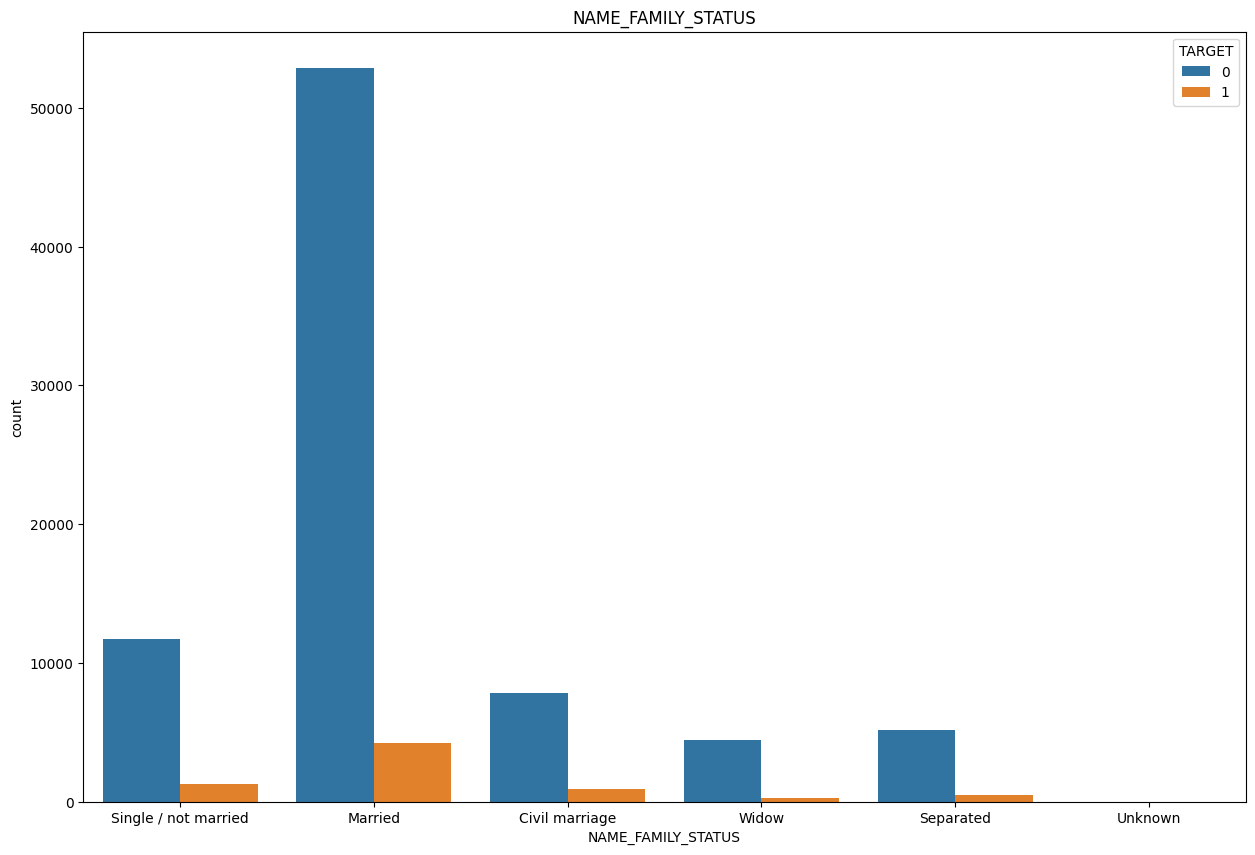

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x='NAME_FAMILY_STATUS',hue='TARGET',data=application_train)
plt.title('NAME_FAMILY_STATUS')
plt.show()

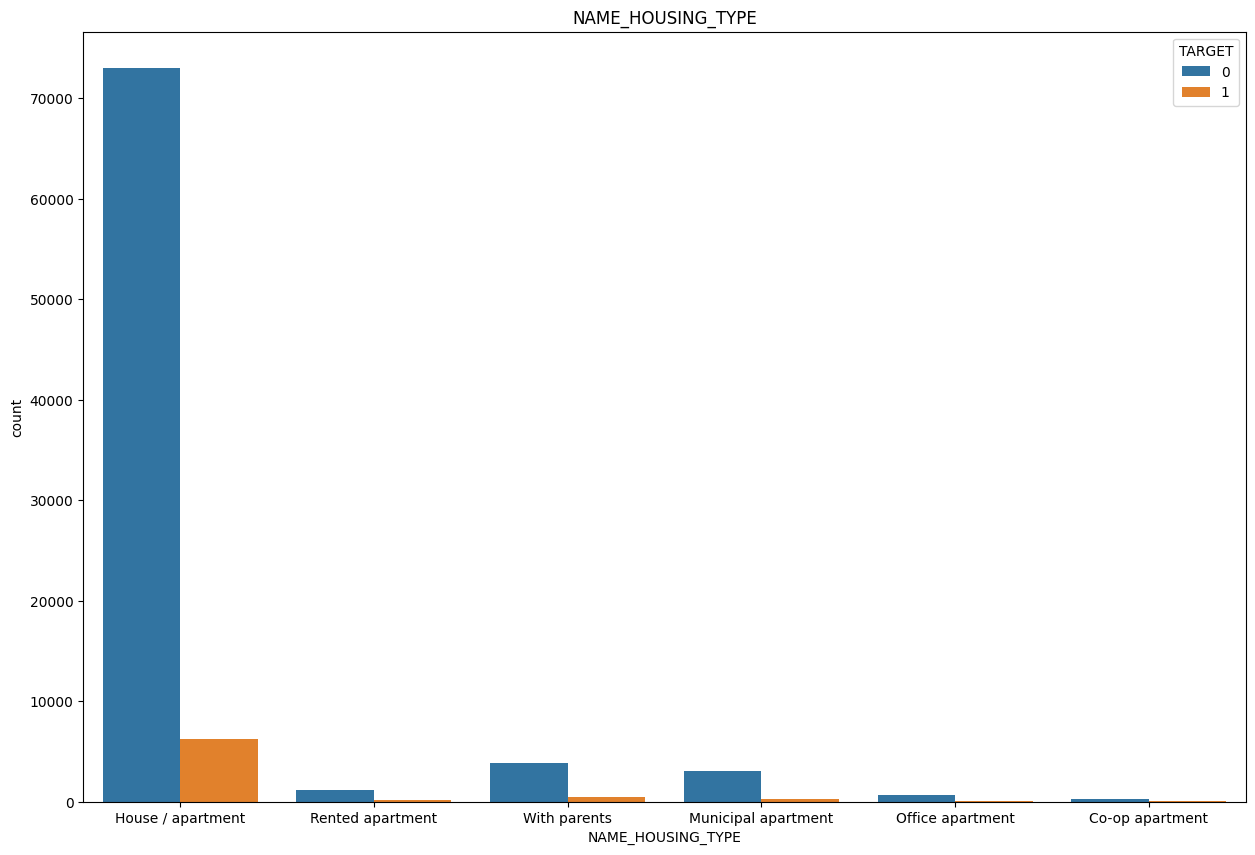

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x='NAME_HOUSING_TYPE',hue='TARGET',data=application_train)
plt.title('NAME_HOUSING_TYPE')
plt.show()

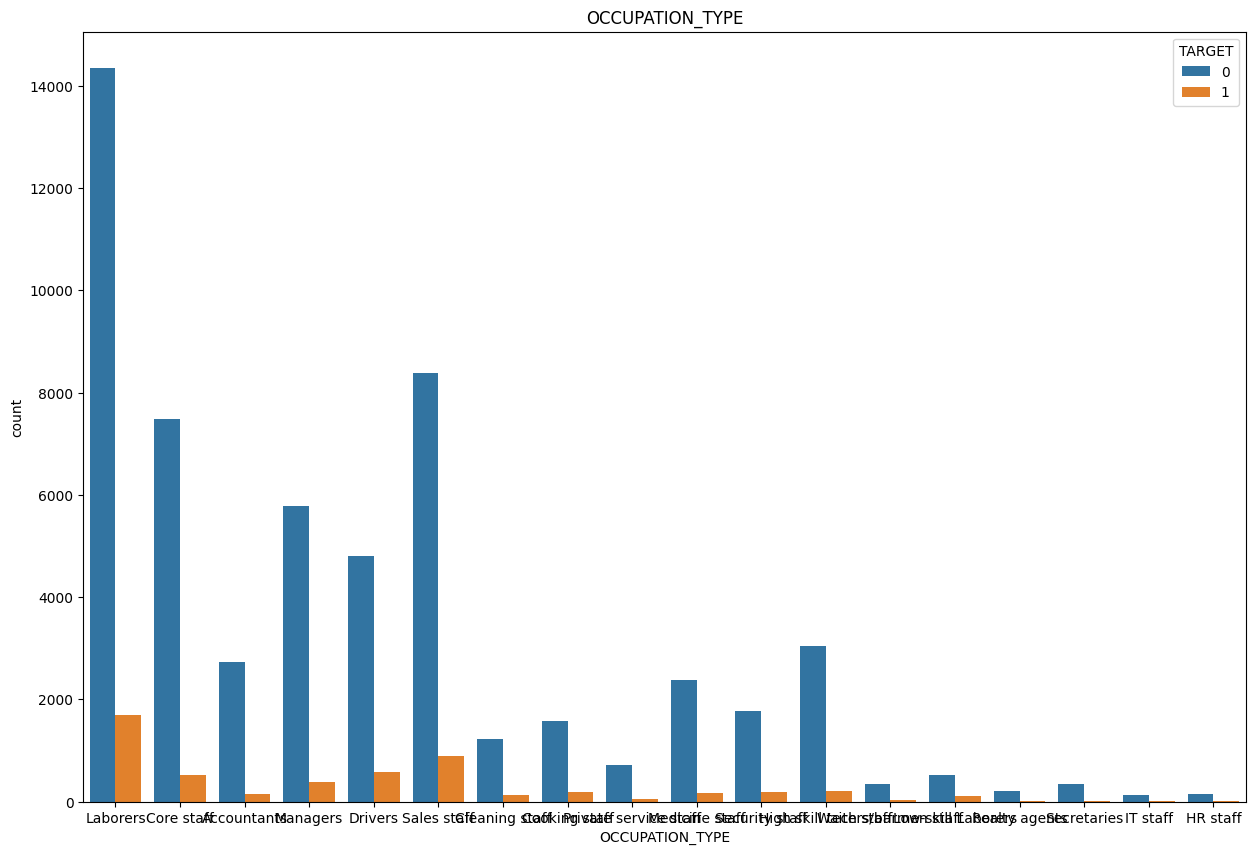

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x='OCCUPATION_TYPE',hue='TARGET',data=application_train)
plt.title('OCCUPATION_TYPE')
plt.show()

In [ ]:
application_train['AMT_INCOME_TOTAL'].value_counts()

,count
AMT_INCOME_TOTAL,
135000.0,10416
112500.0,8947
157500.0,7742
180000.0,7163
90000.0,6488
...,...
882000.0,1
158850.0,1
97915.5,1


In [ ]:
application_train['AMT_INCOME_TOTAL'].unique()

array([202500. , 270000. ,  67500. , ..., 170302.5,  87151.5, 182745. ])

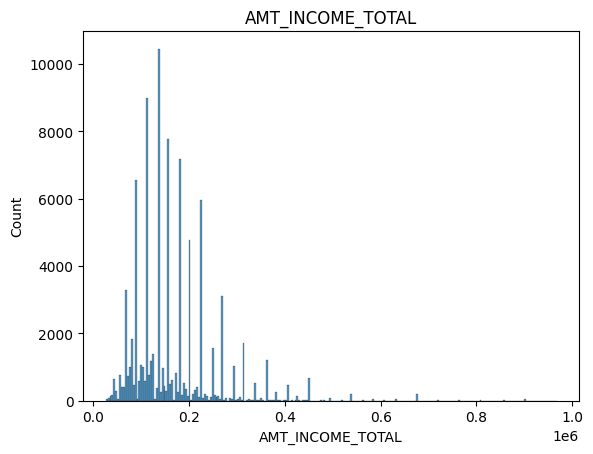

In [ ]:
filtered_data = application_train[application_train['AMT_INCOME_TOTAL']<1000000]
sns.histplot(filtered_data['AMT_INCOME_TOTAL'])
plt.title('AMT_INCOME_TOTAL')
plt.show()

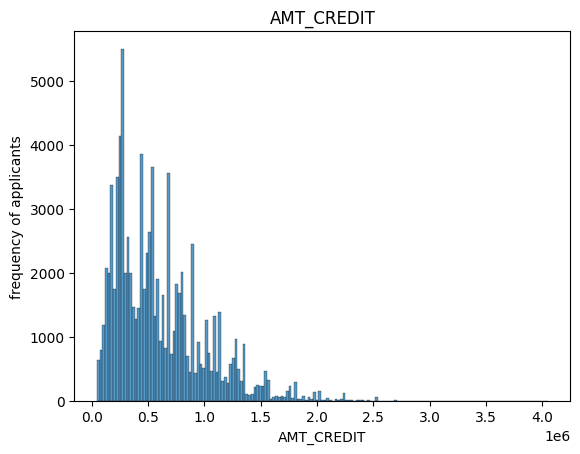

In [ ]:
sns.histplot(application_train['AMT_CREDIT'])
plt.xlabel('AMT_CREDIT')
plt.ylabel('frequency of applicants')
plt.title('AMT_CREDIT')
plt.show()

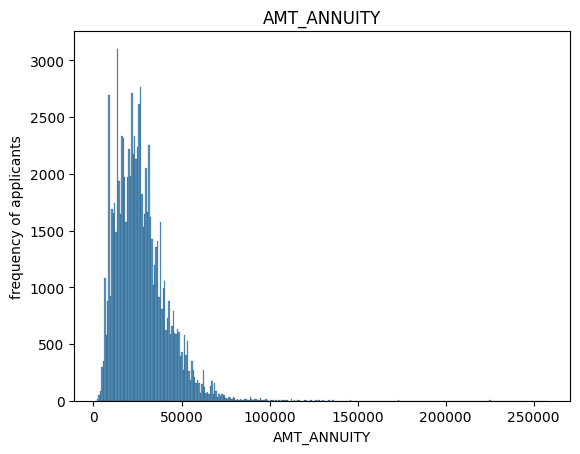

In [ ]:
sns.histplot(application_train['AMT_ANNUITY'])
plt.xlabel('AMT_ANNUITY')
plt.ylabel('frequency of applicants')
plt.title('AMT_ANNUITY')
plt.show()

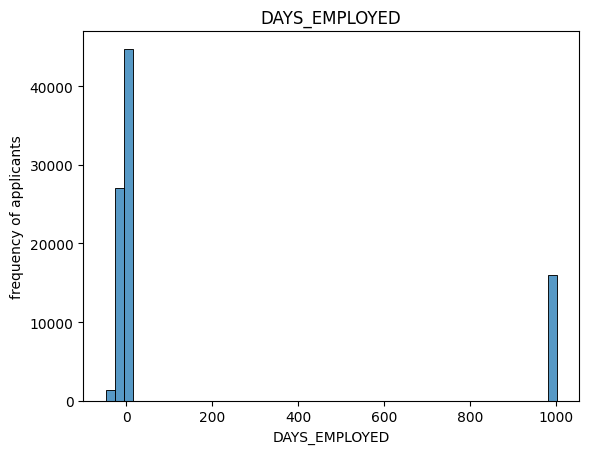

In [ ]:
sns.histplot(application_train['DAYS_EMPLOYED']/365,bins = 50)
plt.xlabel('DAYS_EMPLOYED')
plt.ylabel('frequency of applicants')
plt.title('DAYS_EMPLOYED')
plt.show()

In [ ]:
applicant_age = application_train['DAYS_BIRTH'] / -365
correlation = applicant_age.corr(application_train['TARGET'])
print(f"Correlation between Applicant Age and TARGET: {correlation}")

Correlation between Applicant Age and TARGET: -0.07692019576237398


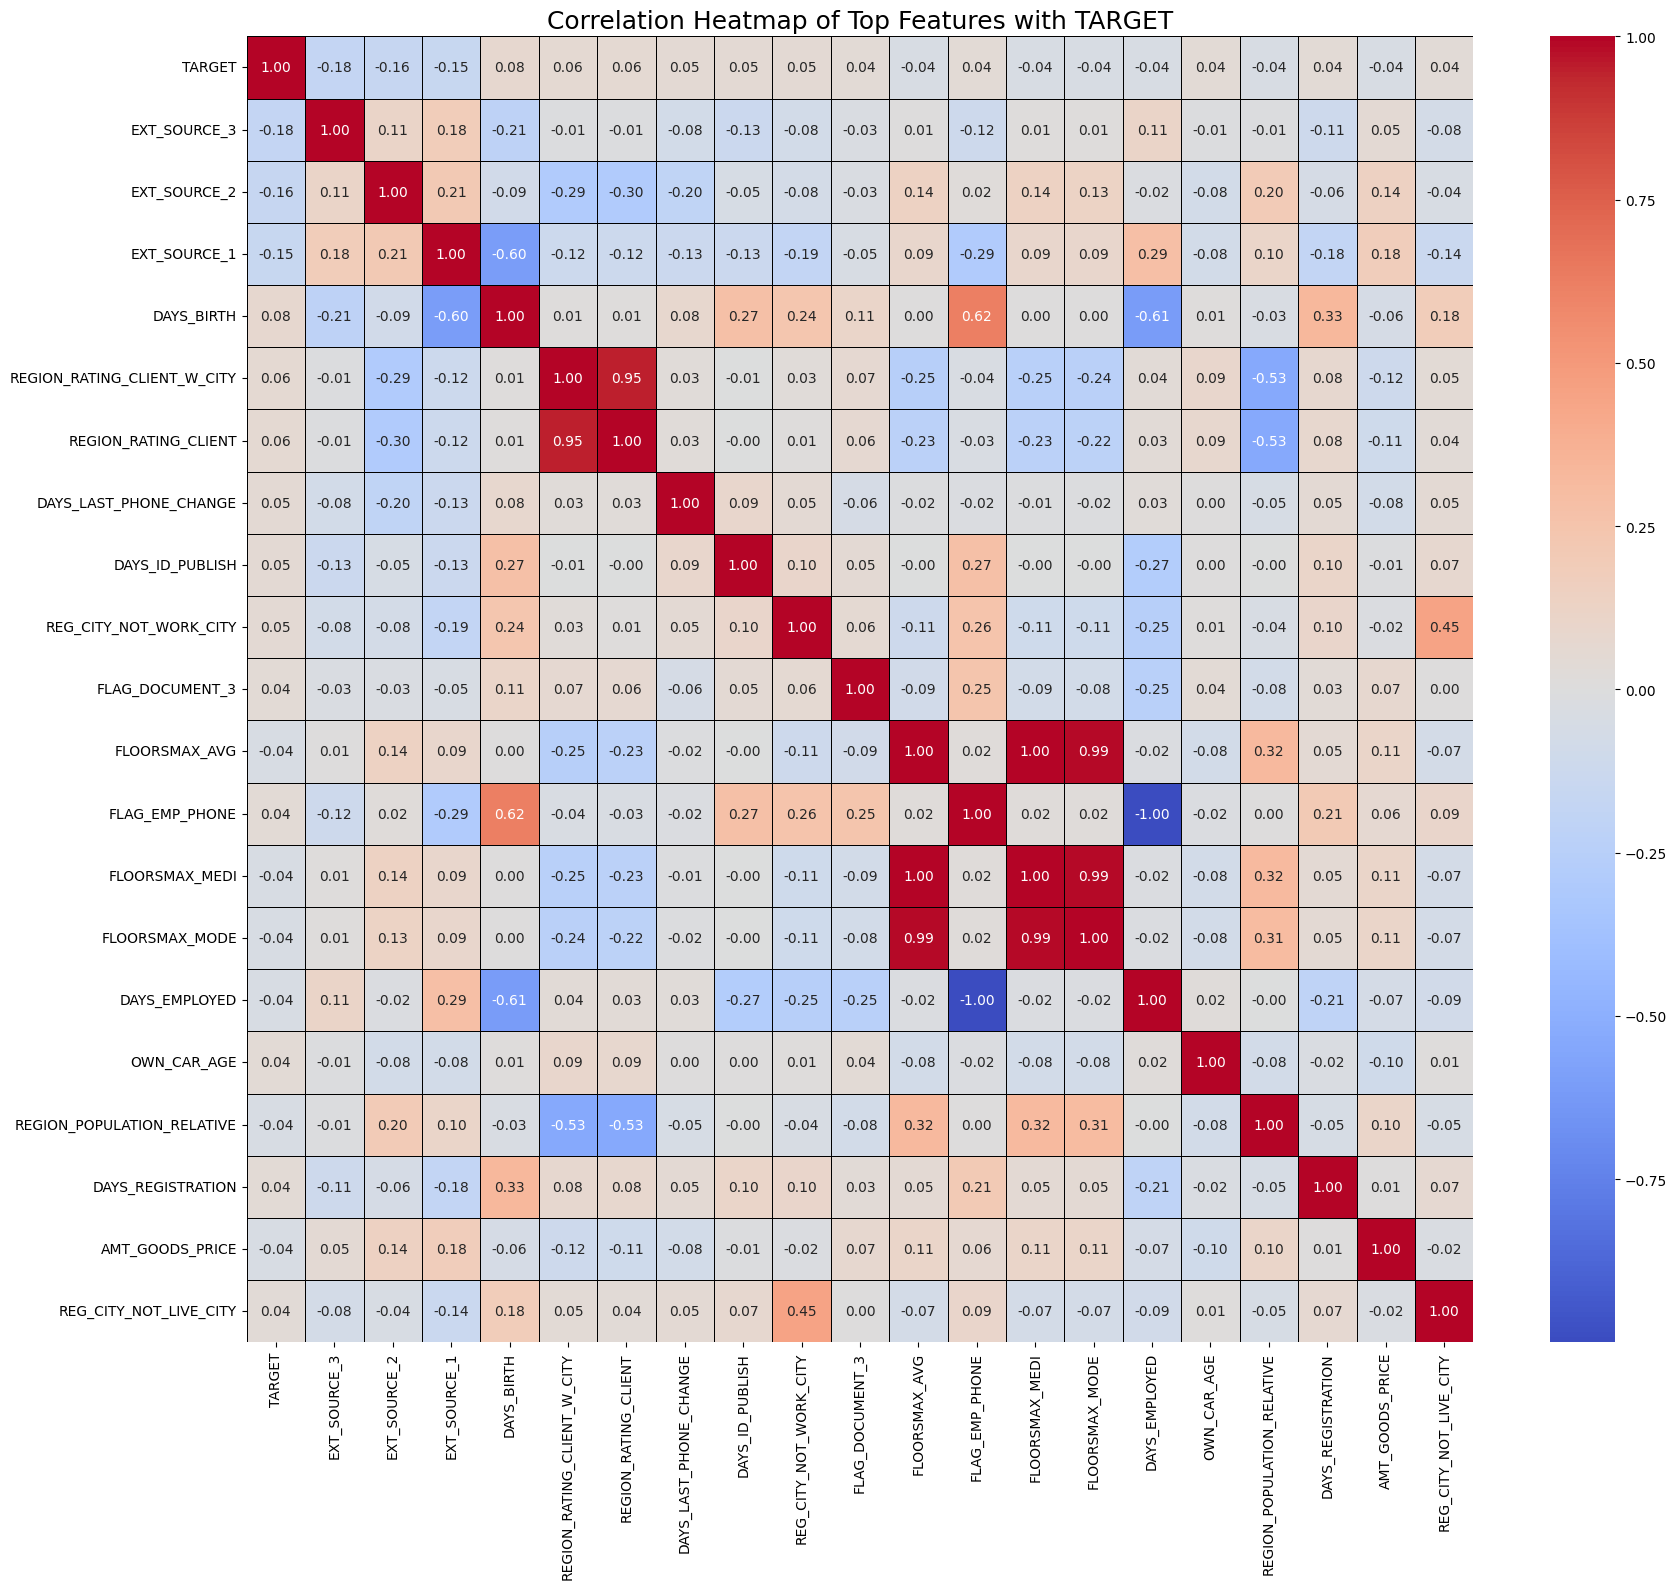

In [ ]:
absolute_target_correlations = correlation_matrix['TARGET'].drop('TARGET').abs().sort_values(ascending=False)

top_correlated_features = absolute_target_correlations.head(20).index.tolist()

selected_features = ['TARGET'] + top_correlated_features

subset_correlation_matrix = application_train[selected_features].corr()

plt.figure(figsize=(18, 16))
sns.heatmap(subset_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Heatmap of Top Features with TARGET', fontsize=18)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

observation

there are categorical data in the application_train.csv

there are 198007 x 122 rows and columns in the data

there are floats,int64,objects in the data

there are no duplicated values in the data

there are 181917 non defaulters,and there are 16090 defaulters also the target data is imbalanced with 91.87% repaying the loans while 8.13%
has not

90.48% of the loans are cash loans while the 9.52% of the loans are revolving loans

there is 65.83% of males and 34.16% of females and 0.00% of XNA

65.99% of the population in the data own a car while the rest of the 34.01% do not own a car

69.37% of the population own a realty while the rest of the population do not

140000+  working and are not defaulters. Also there is a population in the working class that are defaulters.

~20000  state servants and are not defaulters. also there is a small population that is also a defaulter.

~70000  commercial associates and are not defaulters.there is a small population of commerical asssociate who are defaulters.

~50000 pensioners who are not defaulters and there is also a small population that are defaulters

higher educatcated population took fewer loans

the highest loan bearers are the low educated

married population have the highest amount of loans in the data

population that ownes there own house has the highest amount of loans

the histogram shows that most of the applicants have low total income as the income increases the frequency of applicants decreases.

most of applicants who are applying are labor workers

small credit amount is largely taken by the applicants as the credit amount increases the applicants decreases.

as the age of the applicant increase the default rate decreases

#**DATA PREPROCESSING**

In [ ]:
application_train['AMT_GT_CREDIT_FLAG'] = application_train['AMT_INCOME_TOTAL'] > application_train['AMT_CREDIT']
application_train['AMT_GT_ANNUITY_FLAG'] = application_train['AMT_INCOME_TOTAL'] > application_train['AMT_ANNUITY']
application_train['ANNUITY_INCOME_PERCENTAGE'] = application_train['AMT_ANNUITY'] / application_train['AMT_INCOME_TOTAL']
application_train['CREDIT_INCOME_PERCENTAGE'] = application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL']
application_train['DAYS_EMPLOYED_PERCENTAGE'] = application_train['DAYS_EMPLOYED'] / application_train['DAYS_BIRTH']
application_train['DAYS_EMPLOYED_PERCENTAGE'] = application_train['DAYS_EMPLOYED_PERCENTAGE'].apply(lambda x: x if x < 1 else 1)
application_train['CREDIT_TERM'] = application_train['AMT_CREDIT'] / application_train['AMT_ANNUITY']

In [ ]:
application_train.shape

(89237, 127)

### 1. Bureau Balance Numerical Features Aggregation

In [ ]:
print('Processing bureau_balance numerical features...')
bb_numerical = bureau_balance.select_dtypes(include=np.number).drop(columns=['SK_ID_BUREAU'], errors='ignore')
bb_agg_numerical = bureau_balance.groupby('SK_ID_BUREAU')[bb_numerical.columns].mean().reset_index()
new_cols_numerical = {col: 'BUREAU_BALANCE_' + col for col in bb_agg_numerical.columns if col != 'SK_ID_BUREAU'}
bb_agg_numerical = bb_agg_numerical.rename(columns=new_cols_numerical)
bureau = pd.merge(bureau, bb_agg_numerical, on='SK_ID_BUREAU', how='left')
for col in new_cols_numerical.values():
    if col in bureau.columns:
        bureau[col] = bureau[col].fillna(0)
print('Bureau_balance numerical features processed and merged. Shape of bureau:', bureau.shape)

Processing bureau_balance numerical features...
Bureau_balance numerical features processed and merged. Shape of bureau: (539522, 18)


### 2. Bureau Balance Categorical Features Aggregation

In [ ]:
print('Processing bureau_balance categorical features...')
bb_categorical = bureau_balance.select_dtypes(include='object').columns
bb_one_hot = pd.get_dummies(bureau_balance[bb_categorical], columns=bb_categorical, prefix='BUREAU_BALANCE')
bb_one_hot = pd.concat([bureau_balance['SK_ID_BUREAU'], bb_one_hot], axis=1)
bb_agg_categorical = bb_one_hot.groupby('SK_ID_BUREAU').mean().reset_index()
bureau = pd.merge(bureau, bb_agg_categorical, on='SK_ID_BUREAU', how='left')
for col in bb_agg_categorical.columns:
    if col != 'SK_ID_BUREAU' and col in bureau.columns:
        bureau[col] = bureau[col].fillna(0)
print('Bureau_balance categorical features processed and merged. Shape of bureau:', bureau.shape)

Processing bureau_balance categorical features...
Bureau_balance categorical features processed and merged. Shape of bureau: (539522, 26)


### 3. Merge Bureau Numerical Features with Application Train

In [ ]:
print('Merging bureau numerical features with application_train...')
b_numerical_cols_to_agg = bureau.select_dtypes(include=np.number).drop(columns=['SK_ID_BUREAU', 'SK_ID_CURR'], errors='ignore').columns
b_agg_numerical = bureau.groupby('SK_ID_CURR')[b_numerical_cols_to_agg].mean().reset_index()
new_cols_b_numerical = {col: 'BUREAU_' + col for col in b_agg_numerical.columns if col != 'SK_ID_CURR'}
b_agg_numerical = b_agg_numerical.rename(columns=new_cols_b_numerical)
application_train = pd.merge(application_train, b_agg_numerical, on='SK_ID_CURR', how='left')
for col in new_cols_b_numerical.values():
    if col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Bureau numerical features merged with application_train. New shape:', application_train.shape)

Merging bureau numerical features with application_train...
Bureau numerical features merged with application_train. New shape: (89237, 192)


### 4. Merge Bureau Categorical Features with Application Train

In [ ]:
print('Processing bureau categorical features and merging with application_train...')
b_categorical = bureau.select_dtypes(include='object').columns
b_one_hot = pd.get_dummies(bureau[b_categorical], columns=b_categorical, prefix='BUREAU')
b_one_hot = pd.concat([bureau['SK_ID_CURR'], b_one_hot], axis=1)
b_agg_categorical = b_one_hot.groupby('SK_ID_CURR').mean().reset_index()
application_train = pd.merge(application_train, b_agg_categorical, on='SK_ID_CURR', how='left')
for col in b_agg_categorical.columns:
    if col != 'SK_ID_CURR' and col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Bureau categorical features processed and merged. New shape:', application_train.shape)

Processing bureau categorical features and merging with application_train...
Bureau categorical features processed and merged. New shape: (89237, 214)


### 5. Create BUREAU-derived Features

In [ ]:
print('Creating BUREAU-derived features...')
bureau_agg_derived = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_LOAN_TYPES=('CREDIT_TYPE', lambda x: x.nunique())
).reset_index()
cols_to_merge_from_bureau_agg = [col for col in bureau_agg_derived.columns if col != 'SK_ID_CURR']
for col in cols_to_merge_from_bureau_agg:
    if col in application_train.columns:
        print(f"Warning: Column '{col}' already exists in application_train. Dropping it before merge.")
        application_train = application_train.drop(columns=[col])
application_train = pd.merge(application_train, bureau_agg_derived, on='SK_ID_CURR', how='left')
for col_name in ['BUREAU_LOAN_COUNT', 'BUREAU_LOAN_TYPES']:
    if col_name not in application_train.columns:
        print(f"Warning: Column '{col_name}' not found after merge. Initializing to NaN.")
        application_train[col_name] = np.nan
application_train['BUREAU_LOAN_COUNT'] = application_train['BUREAU_LOAN_COUNT'].fillna(0)
application_train['BUREAU_LOAN_TYPES'] = application_train['BUREAU_LOAN_TYPES'].fillna(0)
debt_sum_col = 'BUREAU_AMT_CREDIT_SUM_DEBT'
credit_sum_col = 'BUREAU_AMT_CREDIT_SUM'
if debt_sum_col in application_train.columns and credit_sum_col in application_train.columns:
    application_train['BUREAU_DEBT_CREDIT_RATIO'] = application_train[debt_sum_col] / application_train[credit_sum_col]
    application_train['BUREAU_DEBT_CREDIT_RATIO'] = application_train['BUREAU_DEBT_CREDIT_RATIO'].replace([np.inf, -np.inf], np.nan).fillna(0)
else:
    print(f"Warning: Missing one or both columns for BUREAU_DEBT_CREDIT_RATIO: {debt_sum_col}, {credit_sum_col}. Setting ratio to 0.")
    application_train['BUREAU_DEBT_CREDIT_RATIO'] = 0
overdue_col = 'BUREAU_CREDIT_DAY_OVERDUE'
debt_sum_col_for_overdue = 'BUREAU_AMT_CREDIT_SUM_DEBT'
if overdue_col in application_train.columns and debt_sum_col_for_overdue in application_train.columns:
    application_train['BUREAU_OVERDUE_DEBT_RATIO'] = application_train[overdue_col] / application_train[debt_sum_col_for_overdue]
    application_train['BUREAU_OVERDUE_DEBT_RATIO'] = application_train['BUREAU_OVERDUE_DEBT_RATIO'].replace([np.inf, -np.inf], np.nan).fillna(0)
else:
    print(f"Warning: Missing one or both columns for BUREAU_OVERDUE_DEBT_RATIO: {overdue_col}, {debt_sum_col_for_overdue}. Setting ratio to 0.")
    application_train['BUREAU_OVERDUE_DEBT_RATIO'] = 0
print('BUREAU-derived features created. New shape:', application_train.shape)

Creating BUREAU-derived features...
BUREAU-derived features created. New shape: (89237, 241)


### 6. Process Previous Application Data: Numerical Features

In [ ]:
print('Processing previous_application numerical features...')
prev_numerical_cols = previous_application.select_dtypes(include=np.number).drop(columns=['SK_ID_PREV', 'SK_ID_CURR'], errors='ignore').columns
prev_agg_numerical = previous_application.groupby('SK_ID_CURR')[prev_numerical_cols].mean().reset_index()
new_cols_prev_numerical = {col: 'PREV_' + col for col in prev_agg_numerical.columns if col != 'SK_ID_CURR'}
prev_agg_numerical = prev_agg_numerical.rename(columns=new_cols_prev_numerical)
application_train = pd.merge(application_train, prev_agg_numerical, on='SK_ID_CURR', how='left')
for col in new_cols_prev_numerical.values():
    if col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Previous_application numerical features processed and merged. New shape:', application_train.shape)

Processing previous_application numerical features...
Previous_application numerical features processed and merged. New shape: (89237, 235)


### 7. Process Previous Application Data: Categorical Features

In [ ]:
print('Processing previous_application categorical features...')
prev_categorical_cols = previous_application.select_dtypes(include='object').columns
prev_one_hot = pd.get_dummies(previous_application[prev_categorical_cols], columns=prev_categorical_cols, prefix='PREV')
prev_one_hot = pd.concat([previous_application['SK_ID_CURR'], prev_one_hot], axis=1)
prev_agg_categorical = prev_one_hot.groupby('SK_ID_CURR').mean().reset_index()
application_train = pd.merge(application_train, prev_agg_categorical, on='SK_ID_CURR', how='left')
for col in prev_agg_categorical.columns:
    if col != 'SK_ID_CURR' and col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Previous_application categorical features processed and merged. New shape:', application_train.shape)

Processing previous_application categorical features...
Previous_application categorical features processed and merged. New shape: (89237, 384)


### 8. Process POS_CASH_balance Data: Numerical Features

In [ ]:
print('Processing POS_CASH_balance numerical features...')
pos_numerical_cols = pos_cash_balance.select_dtypes(include=np.number).drop(columns=['SK_ID_PREV', 'SK_ID_CURR'], errors='ignore').columns
pos_agg_numerical = pos_cash_balance.groupby('SK_ID_CURR')[pos_numerical_cols].mean().reset_index()
new_cols_pos_numerical = {col: 'POS_CASH_' + col for col in pos_agg_numerical.columns if col != 'SK_ID_CURR'}
pos_agg_numerical = pos_agg_numerical.rename(columns=new_cols_pos_numerical)
application_train = pd.merge(application_train, pos_agg_numerical, on='SK_ID_CURR', how='left')
for col in new_cols_pos_numerical.values():
    if col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('POS_CASH_balance numerical features processed and merged. New shape:', application_train.shape)

Processing POS_CASH_balance numerical features...
POS_CASH_balance numerical features processed and merged. New shape: (89237, 389)


### 9. Process POS_CASH_balance Data: Categorical Features

In [ ]:
print('Processing POS_CASH_balance categorical features...')
pos_categorical_cols = pos_cash_balance.select_dtypes(include='object').columns
pos_one_hot = pd.get_dummies(pos_cash_balance[pos_categorical_cols], columns=pos_categorical_cols, prefix='POS_CASH')
pos_one_hot = pd.concat([pos_cash_balance['SK_ID_CURR'], pos_one_hot], axis=1)
pos_agg_categorical = pos_one_hot.groupby('SK_ID_CURR').mean().reset_index()
application_train = pd.merge(application_train, pos_agg_categorical, on='SK_ID_CURR', how='left')
for col in pos_agg_categorical.columns:
    if col != 'SK_ID_CURR' and col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('POS_CASH_balance categorical features processed and merged. New shape:', application_train.shape)

Processing POS_CASH_balance categorical features...
POS_CASH_balance categorical features processed and merged. New shape: (89237, 397)


### 10. Process Installments Payments Data: Numerical Features

In [ ]:
print('Processing installments_payments numerical features...')
ip_numerical_cols = installments_payment.select_dtypes(include=np.number).drop(columns=['SK_ID_PREV', 'SK_ID_CURR'], errors='ignore').columns
ip_agg_numerical = installments_payment.groupby('SK_ID_CURR')[ip_numerical_cols].mean().reset_index()
new_cols_ip_numerical = {col: 'IP_' + col for col in ip_agg_numerical.columns if col != 'SK_ID_CURR'}
ip_agg_numerical = ip_agg_numerical.rename(columns=new_cols_ip_numerical)
application_train = pd.merge(application_train, ip_agg_numerical, on='SK_ID_CURR', how='left')
for col in new_cols_ip_numerical.values():
    if col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Installments_payments numerical features processed and merged. New shape:', application_train.shape)

Processing installments_payments numerical features...
Installments_payments numerical features processed and merged. New shape: (89237, 403)


### 11. Process Credit Card Balance Data: Numerical Features

In [ ]:
print('Processing credit_card_balance numerical features...')
cc_numerical_cols = credit_card_balance.select_dtypes(include=np.number).drop(columns=['SK_ID_PREV', 'SK_ID_CURR'], errors='ignore').columns
cc_agg_numerical = credit_card_balance.groupby('SK_ID_CURR')[cc_numerical_cols].mean().reset_index()
new_cols_cc_numerical = {col: 'CC_' + col for col in cc_agg_numerical.columns if col != 'SK_ID_CURR'}
cc_agg_numerical = cc_agg_numerical.rename(columns=new_cols_cc_numerical)
application_train = pd.merge(application_train, cc_agg_numerical, on='SK_ID_CURR', how='left')
for col in new_cols_cc_numerical.values():
    if col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Credit_card_balance numerical features processed and merged. New shape:', application_train.shape)

Processing credit_card_balance numerical features...
Credit_card_balance numerical features processed and merged. New shape: (89237, 423)


### 12. Process Credit Card Balance Data: Categorical Features

In [ ]:
print('Processing credit_card_balance categorical features...')
cc_categorical_cols = credit_card_balance.select_dtypes(include='object').columns
cc_one_hot = pd.get_dummies(credit_card_balance[cc_categorical_cols], columns=cc_categorical_cols, prefix='CC')
cc_one_hot = pd.concat([credit_card_balance['SK_ID_CURR'], cc_one_hot], axis=1)
cc_agg_categorical = cc_one_hot.groupby('SK_ID_CURR').mean().reset_index()
application_train = pd.merge(application_train, cc_agg_categorical, on='SK_ID_CURR', how='left')
for col in cc_agg_categorical.columns:
    if col != 'SK_ID_CURR' and col in application_train.columns:
        application_train[col] = application_train[col].fillna(0)
print('Credit_card_balance categorical features processed and merged. New shape:', application_train.shape)

Processing credit_card_balance categorical features...
Credit_card_balance categorical features processed and merged. New shape: (89237, 430)


### 13. Prepare X and y for Modeling

In [ ]:
print('Preparing X and y for modeling...')
remaining_categorical_cols = application_train.select_dtypes(include='object').columns
application_train = pd.get_dummies(application_train, columns=remaining_categorical_cols)
y = application_train['TARGET']
X = application_train.drop(columns=['TARGET', 'SK_ID_CURR'])
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Data preprocessing complete. X and y are ready for modeling.')

Preparing X and y for modeling...
X shape: (89237, 552)
y shape: (89237,)
Data preprocessing complete. X and y are ready for modeling.


### 14. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

print('Performing train-test split...')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('Train-test split complete.')

Performing train-test split...
X_train shape: (71389, 552)
X_test shape: (17848, 552)
y_train shape: (71389,)
y_test shape: (17848,)
Train-test split complete.


### 15. Numerical Preprocessing: Imputation and Scaling

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print('Starting comprehensive numerical preprocessing...')
X_train_processed = X_train.select_dtypes(exclude='object')
X_test_processed = X_test.select_dtypes(exclude='object')

print('Applying median imputation to training and test data...')
num_imputer = SimpleImputer(strategy='median')
X_train_imputed = num_imputer.fit_transform(X_train_processed)
X_test_imputed = num_imputer.transform(X_test_processed)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train_processed.columns, index=X_train_processed.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test_processed.columns, index=X_test_processed.index)

print('Applying StandardScaler to imputed training and test data...')
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_imputed)
X_test_final = scaler.transform(X_test_imputed)
X_train_final = pd.DataFrame(X_train_final, columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_final = pd.DataFrame(X_test_final, columns=X_test_imputed.columns, index=X_test_imputed.index)

print('Numerical preprocessing complete. All features are now scaled and imputed.')
print('X_train_final shape:', X_train_final.shape)
print('X_test_final shape:', X_test_final.shape)

Starting comprehensive numerical preprocessing...
Applying median imputation to training and test data...
Applying StandardScaler to imputed training and test data...
Numerical preprocessing complete. All features are now scaled and imputed.
X_train_final shape: (71389, 552)
X_test_final shape: (17848, 552)


### Note: Feature Combination and Alignment (Step 17) is no longer required.
### The `X_train_final` and `X_test_final` DataFrames from the numerical preprocessing now contain all preprocessed features.

In [ ]:
%exec_cell 774db5b7

UsageError: Line magic function `%exec_cell` not found.
